In [2]:
import RF_Track as rft
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize, curve_fit
from scipy.stats import norm, chisquare
from flatness import *


RF-Track, version 2.5.4

Copyright (C) 2016-2025 CERN, Geneva, Switzerland. All rights reserved.

Author and contact:
 Andrea Latina <andrea.latina@cern.ch>
 BE-ABP Group
 CERN
 CH-1211 GENEVA 23
 SWITZERLAND

This software is distributed under a CERN proprietary software
license in the hope that it will be useful, but WITHOUT ANY WARRANTY;
not even for MERCHANTABILITY or FITNESS FOR A PARTICULAR PURPOSE.

See the COPYRIGHT and LICENSE files at the top-level directory of
the RF-Track download area: https://gitlab.cern.ch/rf-track

RF-Track was compiled with GSL-2.8 and fftw-3.3.10



[RF-Track] Could not check for updates.


In [3]:
quad_length = float(0.3)  # m
drift_length = float(0.2)
P = 198
N_particles = int(100000)
mass = rft.electronmass
charge = -1

In [33]:
def supergaussian1D(x, A, x0, sigma_x, P):
    return A * np.exp(-( (x-x0)**2 /(2*sigma_x**2) )**P)
    
def r90(sig,P):
    return sig * np.sqrt(2) * (-np.log(0.9))**(1/(2*P))

#80% of central beam
def mask80(x):
    cdf = np.cumsum(x, dtype=float)
    cdf /= cdf[-1] # Normalize CDF to 1
    mask = (cdf >= 0.1) & (cdf <= 0.9) # Mask for central 80%
    return x[mask]

def moving_average(x):
    n = int(len(x)/10)
    """Simple moving average with window size n."""
    return np.convolve(x, np.ones(n)/n, mode='same')
            

def flatness(x):
    
    x = moving_average(x) #smoothing
    x = mask80(x)
    return (max(x)-min(x))/ (max(x)+min(x))

def sum_2gaussians(x, A, x0, sigma_x):
    return A * (np.exp(-( (x-x0)**2 /(2*sigma_x**2) )) + np.exp(-( (x+x0)**2 /(2*sigma_x**2) )) )


In [5]:


def add_s2(lattice, max_thickness, radius, N_slices):
    max_thickness, radius = max_thickness/1000, radius/1000 #convert mm to m
    s2_sigma = radius / 2
    step = radius / (N_slices)
    x = np.arange(-(radius + step), 0, step=step)
    y = norm.pdf(x, 0, s2_sigma)
    y = y - min(y)
    y_scaling_factor = max_thickness / max(y)
    y = y * y_scaling_factor



    for i in range(1, len(y)):
        L = y[i] - y[i - 1]
    
        if L < 0:
            Slice = rft.Absorber(L, 'air')
            Slice.disable_energy_straggling()
            Slice.set_shape ('circular',  abs(x[i]),abs(x[i]) )
            lattice.append(Slice)
        else:
            Slice = rft.Absorber(L,8.897, 13,26.982,2.7, 166)
            Slice.disable_energy_straggling()
            Slice.set_shape ('circular',  abs(x[i]),abs(x[i]) )
            lattice.append(Slice)
    
    


In [10]:
lattice = rft.Lattice()
Drift = rft.Drift(drift_length)
for k1 in [8.23470106,  -5.77519295,  12.30291714, -70.89257372]:
# for k1 in [0,0,0,0]:
    quad = rft.Quadrupole(quad_length, P/charge, k1)
    lattice.append(quad)
    lattice.append(Drift)
lattice.append(rft.Drift(0.1))
add_s2(lattice,9.81019623288435 ,18.9297, 100)
lattice.append(rft.Drift(2.4))


In [11]:
# Twiss = rft.Bunch6d_twiss()
# Twiss.beta_x = 2       # m
# Twiss.beta_y = 2    # m
# Twiss.alpha_x = 0
# Twiss.alpha_y = 0
# Twiss.emitt_x = 1     # mm.mrad normalised emittance
# Twiss.emitt_y = 1     # mm.mrad
# Twiss.mean_xp = 0.0
# Twiss.mean_yp = 0.0
# B0 = rft.Bunch6d_QR(mass, 0.0, charge, P, Twiss, N_particles) #bunch charge can be 0 if dont need collective effects

# x,xp,y,yp = rft.qrandn(N_particles, 4).T
# momentum = np.ones(N_particles)*P # 200 MeV ± 0.5%
sigma_x, sigma_xp, sigma_y, sigma_yp = 1,1,1,1
x = np.random.normal(0, sigma_x, N_particles)
xp = np.random.normal(0, sigma_xp, N_particles)
y = np.random.normal(0, sigma_y, N_particles)
yp = np.random.normal(0, sigma_yp, N_particles)
momentum = P * (1 + np.random.normal(0, 0.5/100, N_particles))  # 200 MeV ± 0.5%
T = np.zeros(N_particles)

matrix = np.column_stack((x, xp, y, yp, T, momentum)) #transpose to match Bunch6d format

B0 = rft.Bunch6d(mass, 0.0, charge, matrix)


In [12]:
B1 = lattice.track(B0)
T = lattice.get_transport_table(
'%S %beta_x %beta_y %alpha_x %alpha_y %sigma_x %sigma_y %sigma_px %sigma_py')
M = B1.get_phase_space('%x %xp %y %yp %E %z')

In [ ]:
def plot_phsp(T,M, n_bins=50,fov=200):
     
    def scatter_hist(x, y, ax, ax_histx, ax_histy):
        
        ax_histx.tick_params(axis="x", labelbottom=True)
        ax_histy.tick_params(axis="y", labelleft=True)

        # the scatter plot:
        ax.scatter(x, y,s=1,alpha=0.5)
        ax.set_xlim(-fov,fov)
        ax.set_ylim(-fov,fov)

        ax.set_xlabel('X (mm)')  # Set x-axis label for scatter plot
        ax.set_ylabel('Y (mm)')

        slice_width = 1
        phsp_xslice = M[(M[:,2] < slice_width)]
        phsp_xslice = phsp_xslice[(phsp_xslice[:,2] > -slice_width)]
        
        phsp_yslice = M[(M[:,0] < slice_width)]
        phsp_yslice = phsp_yslice[(phsp_yslice[:,0] > -slice_width)]

        
        hist_x, bin_edges_x = np.histogram(phsp_xslice[:,0], bins=n_bins, range=[-fov, fov])
        bin_centers_x = (bin_edges_x[:-1] + bin_edges_x[1:]) / 2


        hist_y, bin_edges_y = np.histogram(phsp_yslice[:,2], bins=n_bins, range=[-fov, fov])
        bin_centers_y = (bin_edges_y[:-1] + bin_edges_y[1:]) / 2

        #fits
        p0=[np.max(hist_x),  np.mean(phsp_xslice[:,0]), np.std(phsp_xslice[:,0]), 4]
        params_x, _ = curve_fit(supergaussian1D, bin_centers_x, hist_x, p0=p0)

        params_y, _ = curve_fit(supergaussian1D, bin_centers_y, hist_y, p0=p0)
        xy_fit_curve = np.linspace(-fov, fov, 500)
       
        sig_x,sig_y, P_x, P_y = params_x[2], params_y[2], params_x[3], params_y[3]
        r90_x, r90_y = r90(sig_x, P_x), r90(sig_y, P_y)

        p00 = [np.max(hist_x),  np.mean(phsp_xslice[:,0]), np.std(phsp_xslice[:,0])]
        print( p00)
        p00 = [20,80,50]
        params_xx, _ = curve_fit(sum_2gaussians, bin_centers_x, hist_x, p0=p00)
    
        # Plot SuperGaussian fits

        ax_histx.hist(phsp_xslice[:,0], bins=n_bins, range=[-fov, fov], color="b",alpha=0.6,label= ' X-Intensity')
        ax_histx.plot(xy_fit_curve, supergaussian1D(xy_fit_curve, *params_x), 'r-', label=f"SuperGaussian Fit (P={params_x[3]:.2f},r90={r90_x:.2f})")
        ax_histx.plot(bin_centers_x, moving_average(hist_x), 'k-', label=f'Smoothed (F={flatness(hist_x):.3f})')
        ax_histx.plot(xy_fit_curve, sum_2gaussians(xy_fit_curve, *params_xx), 'g-', label=f"2-Gaussian Fit (x0/sig={params_xx[1]/params_xx[2]:.2f})")
        ax_histx.legend()
        print(params_xx)


        

        ax_histy.hist(phsp_yslice[:,2], bins=n_bins, range=[-fov, fov], color="b",alpha=0.6,label= ' Y-Intensity',orientation="horizontal")
        ax_histy.plot(supergaussian1D(xy_fit_curve, *params_y), xy_fit_curve,  'r-', label=f"SuperGaussian Fit (P={params_y[3]:.2f},r90={r90_x:.2f})")
        ax_histy.plot(moving_average(hist_y),bin_centers_y, 'k-', label=f'Smoothed (F={flatness(hist_y):.3f})')
        ax_histy.legend()

    fig, axs = plt.subplot_mosaic([['histx', '.'],
                                ['scatter', 'histy']],
                                figsize=(10, 8),
                                width_ratios=(4, 1), height_ratios=(1, 4),
                                layout='constrained')
    scatter_hist(M[:,0], M[:,2], axs['scatter'], axs['histx'], axs['histy'])
    plt.show()


[np.int64(26), np.float64(-5.989668213820825), np.float64(89.86621591100239), 4]
[15.57554204 67.01234249 61.21052949]


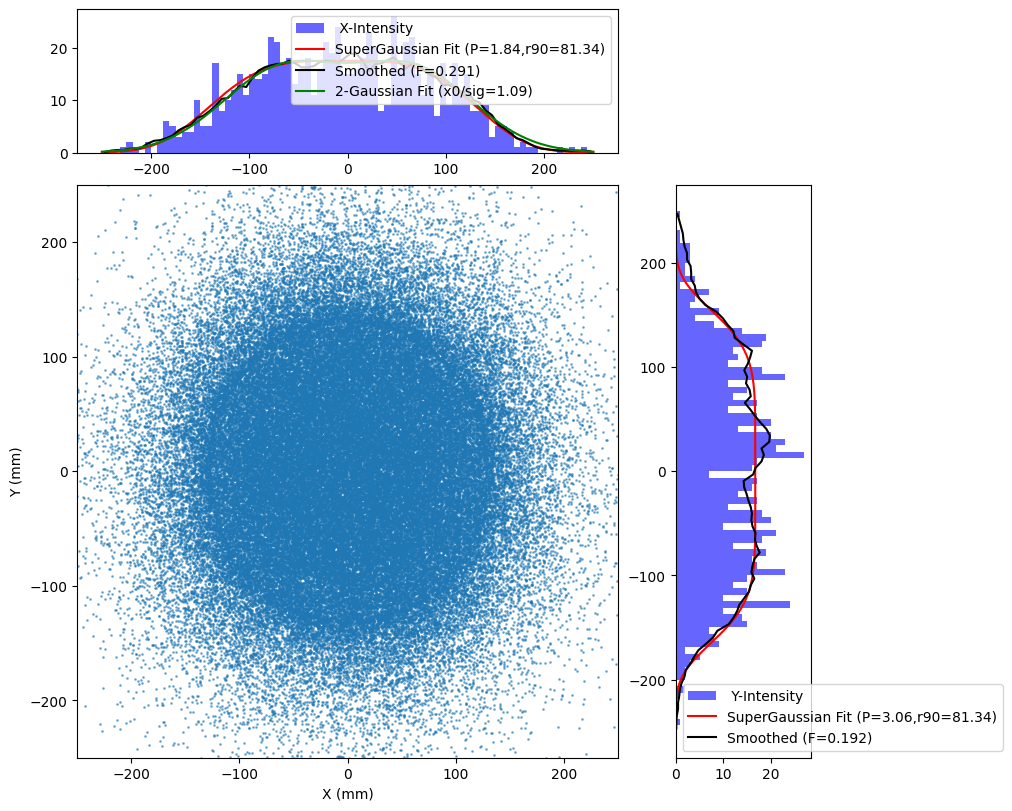

In [41]:
plot_phsp(T,M,80,250)


In [43]:

def kurtosis(x):
    mu = np.mean(x)
    sig = np.std(x)
    return np.mean((x-mu)**4)/sig**4

def supergaussian(x, y, A, x0, y0, sigma_x, sigma_y, P):
    return A * np.exp(-( (x-x0)**2 /(2*sigma_x**2) + (y-y0)**2 /(2*sigma_y**2))**P)

def MSE(params, x, y, dose_map):
    model = supergaussian(x, y, *params)
    return np.sum((model - dose_map)**2) 
    
def loss (params):
    s2_l, s2_r = params
    lattice = rft.Lattice()
    Drift = rft.Drift(drift_length)
    k1s = [8.23470106,  -5.77519295,  12.30291714, -70.89257372]
    for k1 in k1s :
        quad = rft.Quadrupole(quad_length, P/charge, k1)
        lattice.append(quad)
        lattice.append(Drift)
    lattice.append(rft.Drift(0.1))
    add_s2(lattice, s2_l, s2_r, 100)
    lattice.append(rft.Drift(2))

    B1 = lattice.track(B0)
    T = lattice.get_transport_table(
    '%S %beta_x %beta_y %alpha_x %alpha_y %sigma_x %sigma_y %sigma_px %sigma_py')
    M = B1.get_phase_space('%x %xp %y %yp %E %z')
    x,y = M[:,0], M[:,2]
    

    # p0=[np.mean(x), np.max(x)//2, np.max(y)//2, np.std(x), np.std(y), 6]
    #curvefit 2d histogram to supergaussian
    # Perform the optimization
    # result = minimize(MSE, p0, args=(x, y, doseMap), method='L-BFGS-B')

    slice_width = 1
    n_bins,fov  = 15,250
    phsp_xslice = M[(M[:,2] < slice_width)]
    phsp_xslice = phsp_xslice[(phsp_xslice[:,2] > -slice_width)]
    
    phsp_yslice = M[(M[:,0] < slice_width)]
    phsp_yslice = phsp_yslice[(phsp_yslice[:,0] > -slice_width)]
    
    
    hist_x, bin_edges_x = np.histogram(phsp_xslice[:,0], bins=n_bins, range=[-fov, fov])
    bin_centers_x = (bin_edges_x[:-1] + bin_edges_x[1:]) / 2
    hist_y, bin_edges_y = np.histogram(phsp_yslice[:,2], bins=n_bins, range=[-fov, fov])
    bin_centers_y = (bin_edges_y[:-1] + bin_edges_y[1:]) / 2

    # loss = nearest_neighbor_test(x,y)[2]
    # loss = flatness(hist_x) + flatness(hist_y)
    loss = merit_beam_Uniform(B1, 70, 80, transmission=0.998)
    p0 = [np.max(hist_x),  10, np.std(phsp_xslice[:,0])]
    params_x, _ = curve_fit(sum_2gaussians, bin_centers_x, hist_x, p0=p0)
    params_y, _ = curve_fit(sum_2gaussians, bin_centers_y, hist_y, p0=p0) 
    loss = abs(params_x[1]/params_x[2] -1.1)  + abs(params_y[1]/params_y[2] -1.1) #x0/sigma  

    # masked_x, masked_y = mask2d(M[:,0],M[:,2])
    # loss = nearest_neighbor_test(masked_x,masked_y)[2]
    
    print('s2_l:',params[0],',s2_r:',params[1],',loss:',loss,flatness(hist_x),flatness(hist_y))
    return loss
    

In [ ]:
x0 = [6,12]
res = minimize(loss,
                      x0=x0,
                      bounds=[ (0,10),(0,20)], #for k1_1, k1_2, k1_3, k1_4
                      method='Powell',)

print(f'Trial {_}: M={res.fun:.2f}, k1s, s2_l, s2_r={res.x}')

s2_l: 6.0 ,s2_r: 12.0 ,loss: 0.4266949180463442 0.38461538461538464 0.3858267716535433
s2_l: 3.819660112501051 ,s2_r: 12.0 ,loss: 0.2047327791998692 0.4132231404958678 0.3949579831932773
s2_l: 6.180339887498947 ,s2_r: 12.0 ,loss: 0.14962271999362264 0.35344827586206895 0.36
s2_l: 7.639320225002102 ,s2_r: 12.0 ,loss: 2.709095345304971 0.35319148936170214 0.2982456140350877
s2_l: 5.0250810817704314 ,s2_r: 12.0 ,loss: 0.4215545356711148 0.3924050632911392 0.42971887550200805


/var/folders/js/yc7tw1214zg2_b4s8hs1l23h0000gp/T/ipykernel_27958/4061088930.py:57: OptimizeWarning: Covariance of the parameters could not be estimated
  params_y, _ = curve_fit(sum_2gaussians, bin_centers_y, hist_y, p0=p0)


s2_l: 6.7376207875073595 ,s2_r: 12.0 ,loss: 10.04945195312679 0.38271604938271603 0.3593073593073593
s2_l: 5.739070289513267 ,s2_r: 12.0 ,loss: 10.253230852738373 0.4098360655737705 0.3652173913043478
s2_l: 6.393202250021029 ,s2_r: 12.0 ,loss: 9.823551488164004 0.3888888888888889 0.3852813852813853
s2_l: 6.011789899270419 ,s2_r: 12.0 ,loss: 0.46170739707851327 0.3271889400921659 0.36796536796536794
s2_l: 6.261646075056781 ,s2_r: 12.0 ,loss: 0.39637718289916735 0.3537117903930131 0.32407407407407407
s2_l: 6.115959520799045 ,s2_r: 12.0 ,loss: 0.4379312564842712 0.35344827586206895 0.35398230088495575
s2_l: 6.211396087650367 ,s2_r: 12.0 ,loss: 0.43598513755888413 0.3884297520661157 0.3702127659574468
s2_l: 6.1557487756277665 ,s2_r: 12.0 ,loss: 0.43472779572196263 0.36752136752136755 0.3891213389121339
s2_l: 6.19220230039537 ,s2_r: 12.0 ,loss: 0.5913386193110832 0.3898305084745763 0.39748953974895396
s2_l: 6.170946918585307 ,s2_r: 12.0 ,loss: 0.42710257255851114 0.31797235023041476 0.41129

In [ ]:
slice_width = 1
n_bins,fov  = 15,250
phsp_xslice = M[(M[:,2] < slice_width)]
phsp_xslice = phsp_xslice[(phsp_xslice[:,2] > -slice_width)]

phsp_yslice = M[(M[:,0] < slice_width)]
phsp_yslice = phsp_yslice[(phsp_yslice[:,0] > -slice_width)]


hist_x, bin_edges_x = np.histogram(phsp_xslice[:,0], bins=n_bins, range=[-fov, fov])
bin_centers_x = (bin_edges_x[:-1] + bin_edges_x[1:]) / 2


hist_y, bin_edges_y = np.histogram(phsp_yslice[:,2], bins=n_bins, range=[-fov, fov])
bin_centers_y = (bin_edges_y[:-1] + bin_edges_y[1:]) / 2

plt.scatter(bin_edges_y[:len(hist_y)],hist_y)
plt.plot(bin_edges_y[:len(hist_y)],moving_average(hist_y))

plt.figure()


In [35]:
from sklearn.neighbors import NearestNeighbors

def nearest_neighbor_test(x,y):
    points = np.array([x,y]).T
    nbrs = NearestNeighbors(n_neighbors=2).fit(points)
    distances, _ = nbrs.kneighbors(points)
    nn_distances = distances[:, 1]  # skip self-distance

    mean_dist = nn_distances.mean()
    std_dist = nn_distances.std()
    print(nn_distances)
    cv = std_dist / mean_dist  
    # coefficient of variation = 0.52 is poisson uniform, <0.52 is too uniform, >0.52 clustering

    return mean_dist, std_dist, cv

def mask2d(x,y):
    r = np.sqrt(x**2 + y**2)
    threshold = np.percentile(r, 60)
    mask = r <= threshold
    return x[mask],y[mask]

In [50]:
masked_x, masked_y = mask2d(M[:,0],M[:,2])
nearest_neighbor_test(masked_x,masked_y)

[0.50806436 0.34145749 0.36077745 ... 0.78139585 0.48378255 0.34475698]


(np.float64(0.42907209079396347),
 np.float64(0.22426861441030715),
 np.float64(0.5226828293476653))

In [14]:
merit_beam_Uniform(B1, 70, 80, transmission=0.998)

644.6770008386579 19179.76287206852 0.0 0.0 134.85474680566284


np.float64(19824.43987290718)

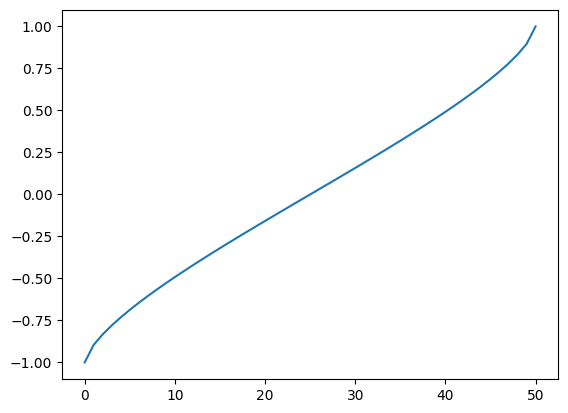

In [76]:
def A(y):
    return 100 * (np.arcsin(y) / np.pi + (y * np.sqrt(1 - y**2)) / np.pi + 0.5)
PRC = np.arange(0, 102, 2) 
# inverse via argmin (fminbound)
PRC_UniformDisk = np.array([
    fminbound(lambda x: (A(x) - p)**2, -1, 1)
    for p in PRC
])
plt.plot(PRC_UniformDisk)
plt.show()


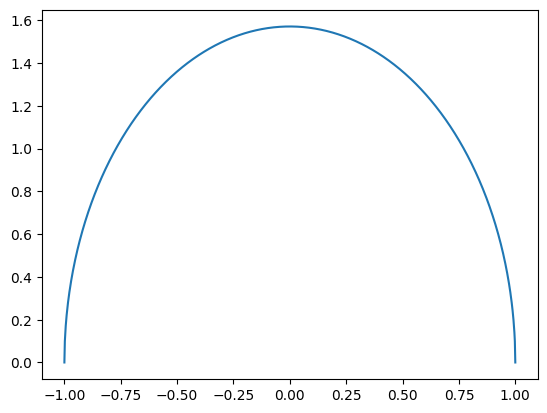

In [106]:
x = np.linspace(-1,1,1000)
y = np.pi * np.sqrt(1-x**2) /2
plt.plot(x,y)

In [17]:
q = lattice.get_quadrupoles()

In [ ]:
q.set